In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [10]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"

columns = [
    "mpg", "cylinders", "displacement", "horsepower",
    "weight", "acceleration", "model_year", "origin", "car_name"
]

pd.read_csv(url, sep=r"\s+", names=columns, na_values="?")

df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,USA,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,USA,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,USA,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,USA,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,USA,ford torino


In [3]:
df.info()
df.describe()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car_name      398 non-null    object 
dtypes: float64(5), int64(3), object(1)
memory usage: 28.1+ KB


,0
mpg,0
cylinders,0
displacement,0
horsepower,6
weight,0
acceleration,0
model_year,0
origin,0
car_name,0


In [4]:
df["horsepower"] = pd.to_numeric(df["horsepower"])

In [5]:
df = df.dropna()

In [6]:
origin_map = {1: "USA", 2: "Asia", 3: "Europe"}
df["origin"] = df["origin"].map(origin_map)

df["origin"].value_counts()

,count
origin,
USA,245
Europe,79
Asia,68


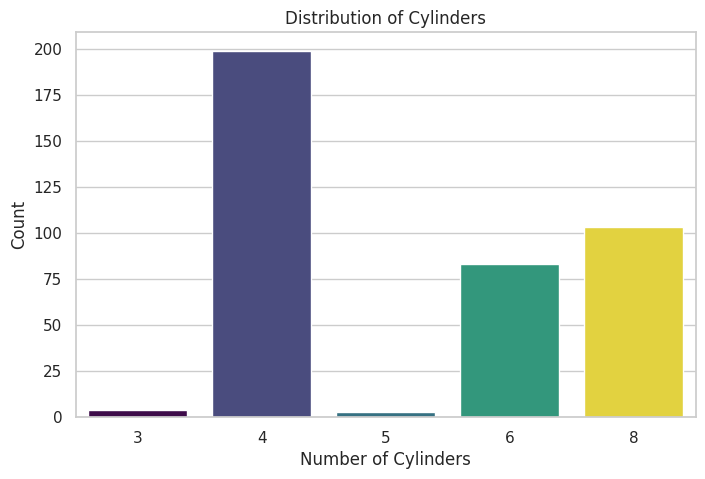

In [11]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="cylinders", hue="cylinders", palette="viridis", legend=False)

plt.title("Distribution of Cylinders")
plt.xlabel("Number of Cylinders")
plt.ylabel("Count")

plt.show()

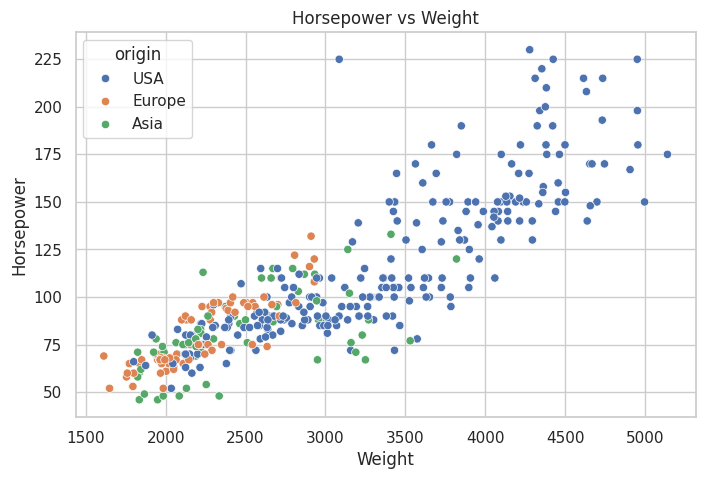

In [8]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="weight", y="horsepower", hue="origin")

plt.title("Horsepower vs Weight")
plt.xlabel("Weight")
plt.ylabel("Horsepower")

plt.show()

## Question

### How does horsepower affect fuel efficiency (MPG)?


  There is a strong negative relationship between horsepower and MPG, indicating that as horsepower increases, fuel efficiency tends to decrease. In other words, vehicles with more powerful engines generally consume more fuel, resulting in lower MPG values. This pattern suggests that higher performance comes at the cost of reduced fuel efficiency.

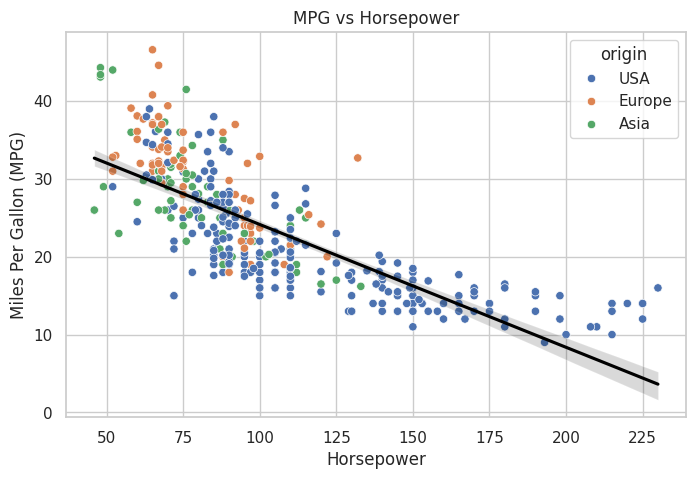

In [9]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="horsepower", y="mpg", hue="origin")
sns.regplot(data=df, x="horsepower", y="mpg", scatter=False, color="black")

plt.title("MPG vs Horsepower")
plt.xlabel("Horsepower")
plt.ylabel("Miles Per Gallon (MPG)")

plt.show()